# Linear Regression — Complete Experiment

**Dataset:** California Housing (sklearn)  
**Target:** `MedHouseVal` — Median house value in $100k

### Pipeline
| # | Step |
|---|------|
| 1 | Load & Inspect Data |
| 2 | EDA — Distributions, Correlations, Pairplots |
| 3 | Outlier Detection & Treatment (IQR) |
| 4 | Feature Engineering — Interactions & Skewness Fix |
| 5 | Feature Selection — Correlation Filter + VIF |
| 6 | Preprocessing — Train/Test Split + Scaling |
| 7 | Linear Regression from Scratch (NumPy) |
| 8 | Linear Regression with Sklearn |
| 9 | Evaluation & Overfitting Diagnostics |
| 10 | Regularization — Ridge & Lasso Comparison |
| 11 | Residual Diagnostics |
| 12 | Summary |

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("All imports loaded.")

All imports loaded.


---
## 1. Load & Inspect Data

The California Housing dataset contains 20,640 samples with 8 features describing block-level census data.

| Feature | Description |
|---------|-------------|
| MedInc | Median income in block group |
| HouseAge | Median house age |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | Block group population |
| AveOccup | Average household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |

In [56]:
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df.head()

Shape: (20640, 9)
Missing values: 0
Duplicates: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## 2. EDA — Distributions, Correlations, Pairplots

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


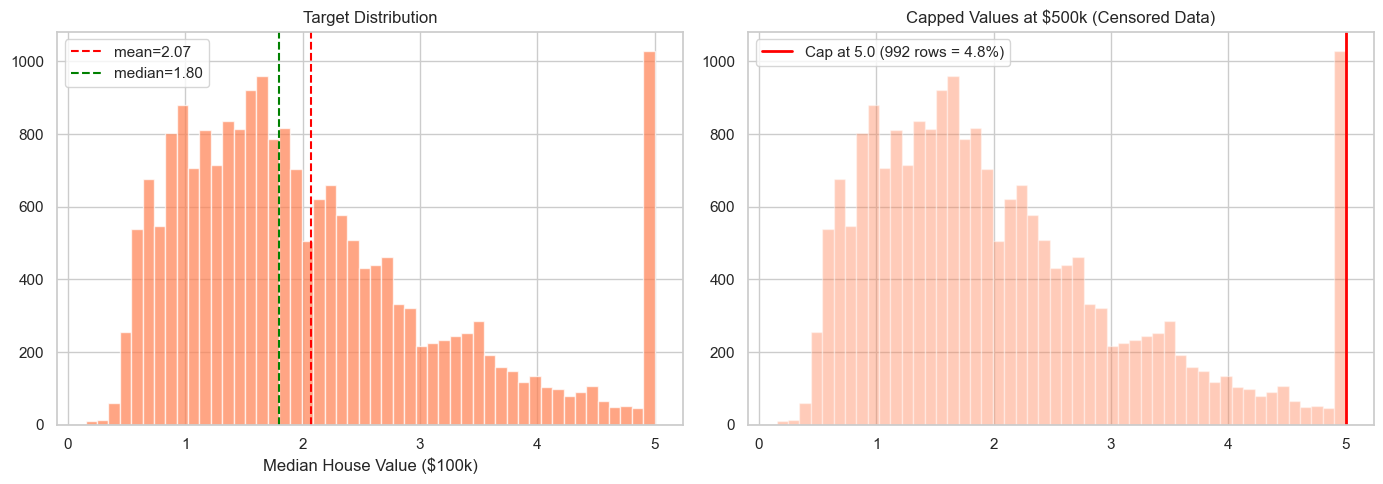

Removed 992 capped rows → 19648 rows remaining


In [58]:
# Target distribution — check for capped values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='coral', edgecolor='white', alpha=0.7)
axes[0].axvline(df['MedHouseVal'].mean(), color='red', ls='--', label=f"mean={df['MedHouseVal'].mean():.2f}")
axes[0].axvline(df['MedHouseVal'].median(), color='green', ls='--', label=f"median={df['MedHouseVal'].median():.2f}")
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_title('Target Distribution')
axes[0].legend()

n_capped = (df['MedHouseVal'] >= 5.0).sum()
axes[1].hist(df['MedHouseVal'], bins=50, color='coral', edgecolor='white', alpha=0.4)
axes[1].axvline(5.0, color='red', lw=2, label=f'Cap at 5.0 ({n_capped} rows = {n_capped/len(df)*100:.1f}%)')
axes[1].set_title('Capped Values at $500k (Censored Data)')
axes[1].legend()
plt.tight_layout()
plt.show()

# Remove capped values — these are censored, not true prices
df = df[df['MedHouseVal'] < 5.0].copy()
print(f"Removed {n_capped} capped rows → {len(df)} rows remaining")

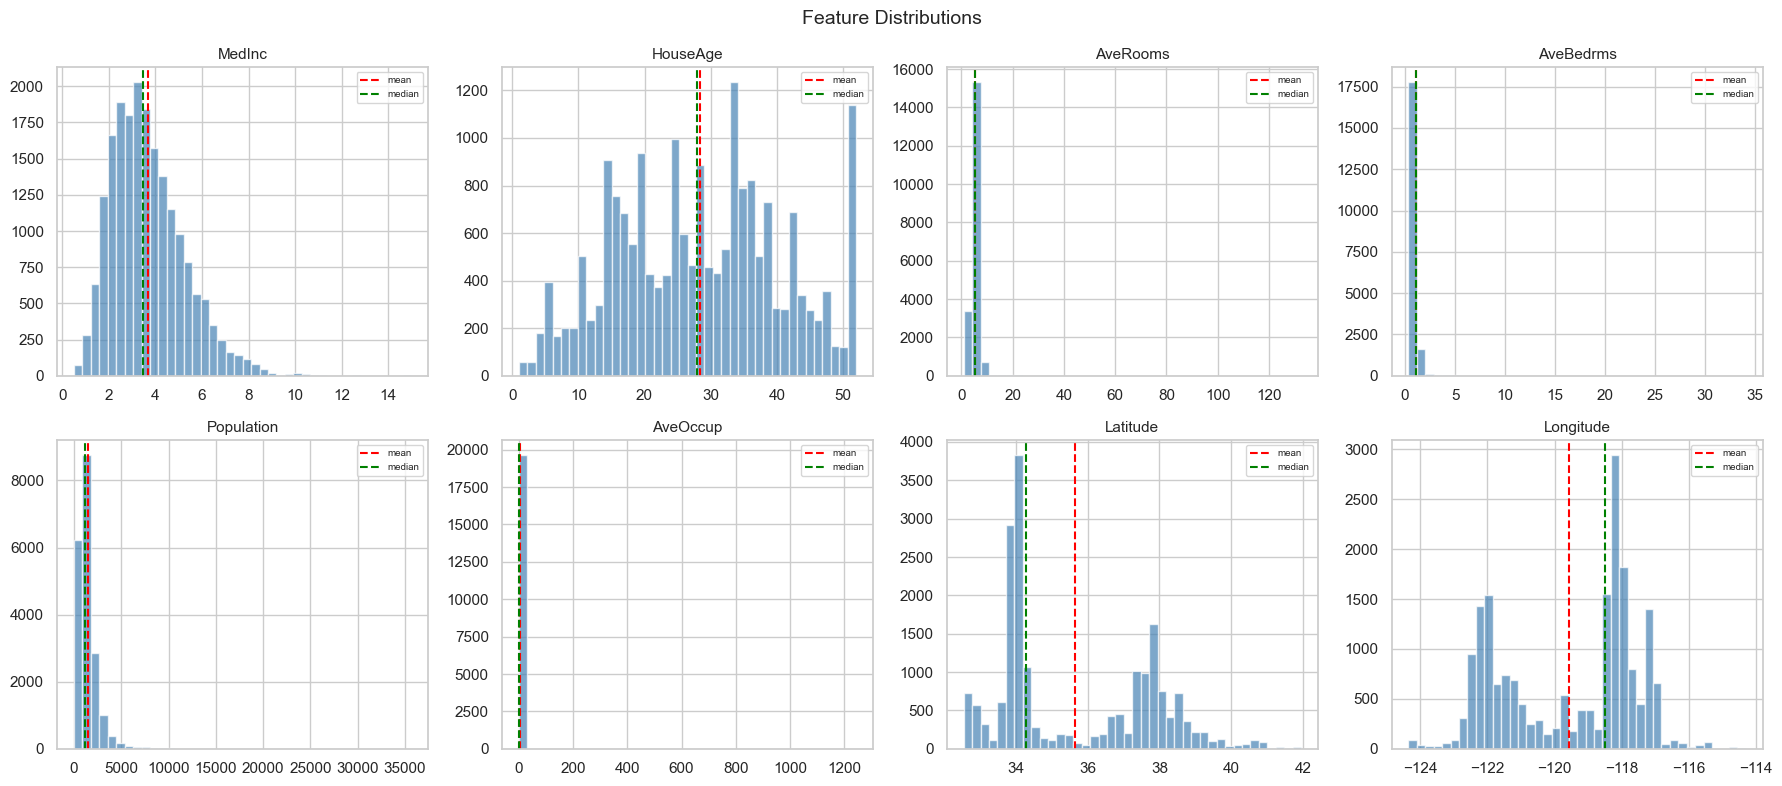

In [59]:
# Feature distributions — check for skew and spread
numeric_cols = df.columns.drop('MedHouseVal')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.axvline(df[col].mean(), color='red', ls='--', lw=1.5, label='mean')
    ax.axvline(df[col].median(), color='green', ls='--', lw=1.5, label='median')
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

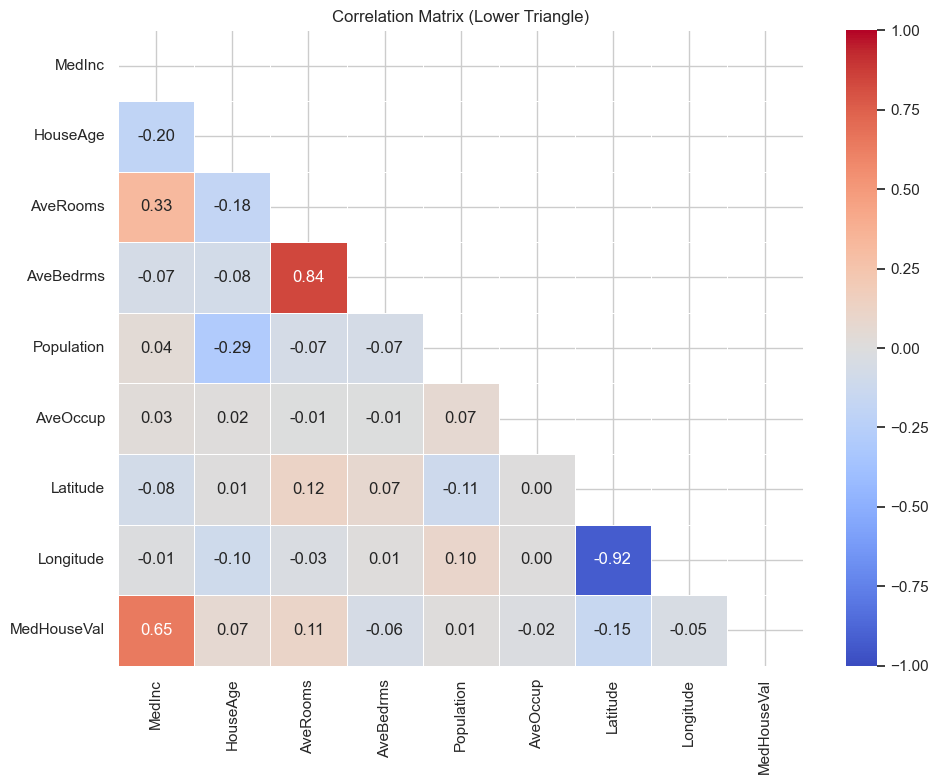

Feature correlation with target (|r|):
  MedInc       0.647 ███████████████████
  Latitude     0.149 ████
  AveRooms     0.112 ███
  HouseAge     0.065 █
  AveBedrms    0.061 █
  Longitude    0.046 █
  AveOccup     0.021 
  Population   0.014 


In [60]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

# Rank features by correlation with target
target_corr = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
print("Feature correlation with target (|r|):")
for feat, r in target_corr.items():
    bar = "█" * int(r * 30)
    print(f"  {feat:<12} {r:.3f} {bar}")

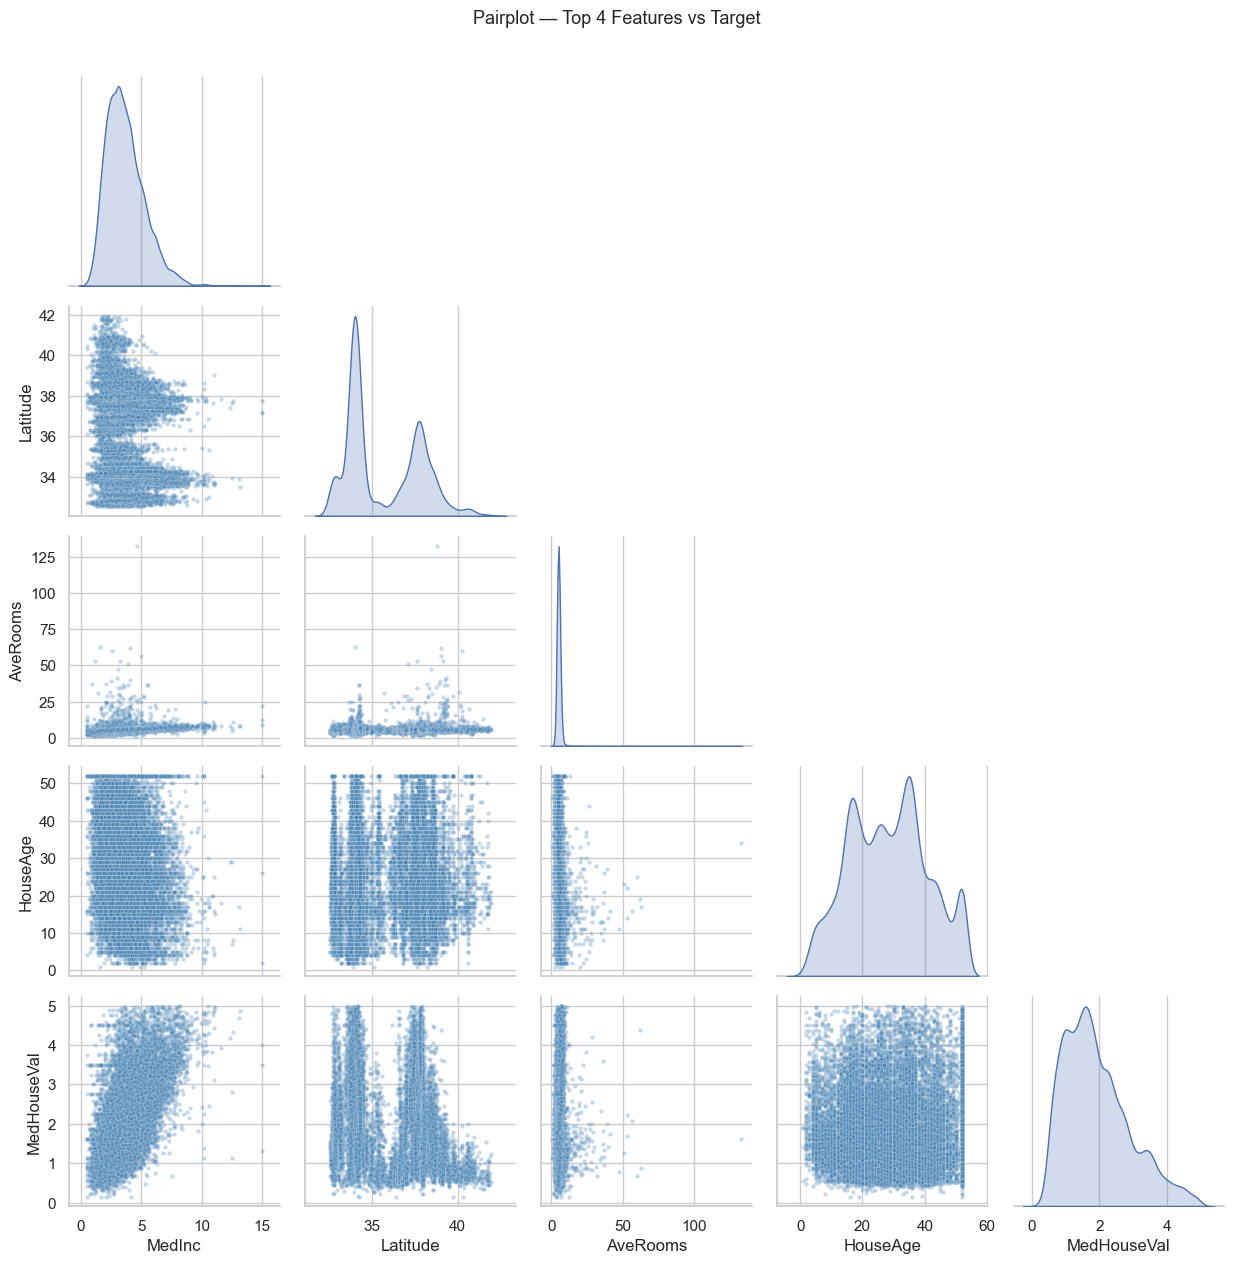

In [61]:
# Pairplot of top-4 correlated features vs target
top_features = target_corr.head(4).index.tolist()
sns.pairplot(df[top_features + ['MedHouseVal']], corner=True, diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'})
plt.suptitle(f"Pairplot — Top 4 Features vs Target", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Outlier Detection & Treatment (IQR)

Linear Regression minimizes squared error — a single extreme point can drag the line significantly.  
We use the **IQR method** to cap extreme values rather than drop them (preserves data).

Feature         Outliers        %
---------------------------------
MedInc          364          1.9%
HouseAge        0            0.0%
AveRooms        450          2.3%
AveBedrms       1354         6.9%
Population      1126         5.7%
AveOccup        662          3.4%
Latitude        0            0.0%
Longitude       0            0.0%


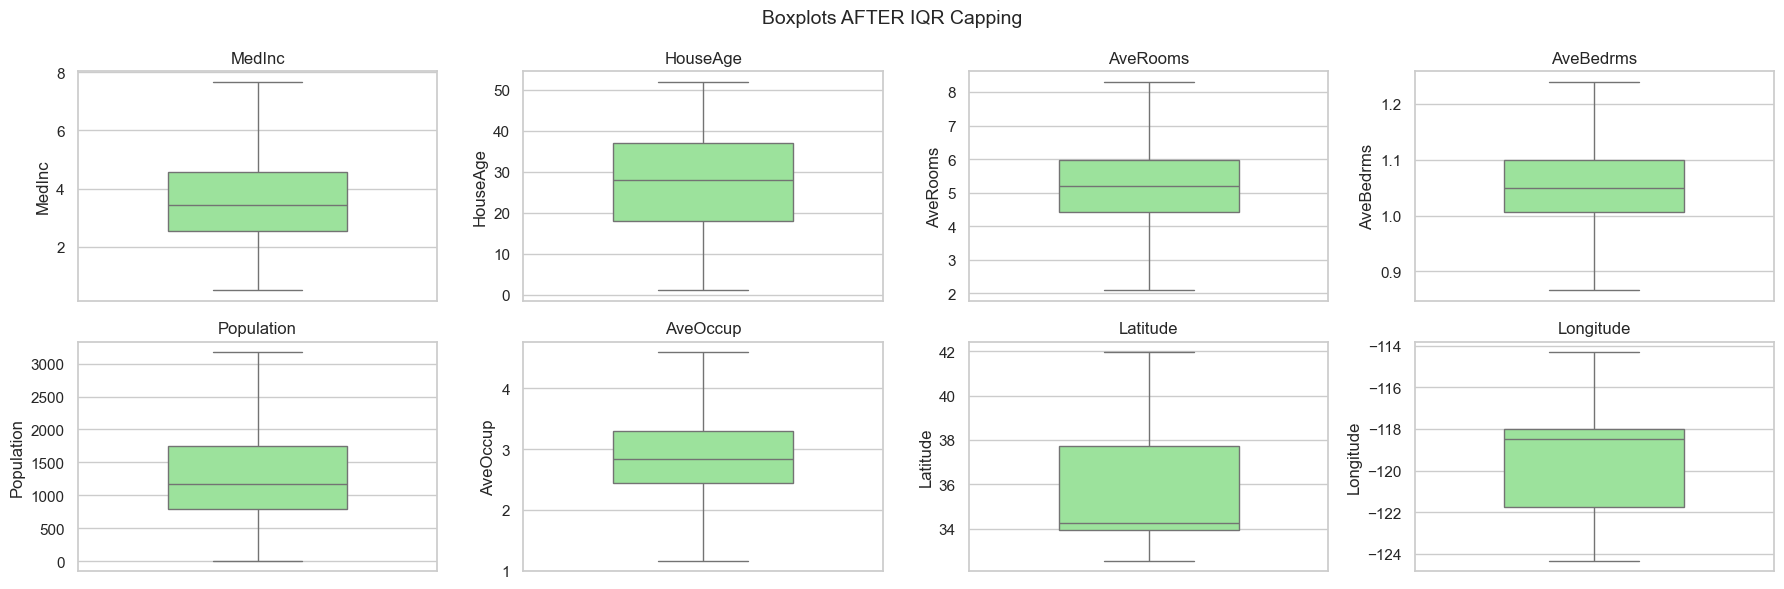

All outliers capped.


In [62]:
# Count outliers per feature BEFORE treatment
print(f"{'Feature':<15} {'Outliers':<10} {'%':>6}")
print("-" * 33)
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col:<15} {n_out:<10} {n_out / len(df) * 100:>5.1f}%")

# Apply IQR capping
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Boxplots AFTER treatment
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen', width=0.5)
    ax.set_title(col)
plt.suptitle("Boxplots AFTER IQR Capping", fontsize=14)
plt.tight_layout()
plt.show()
print("All outliers capped.")

---
## 4. Feature Engineering

### New interaction features
Domain-driven features that combine raw columns into more meaningful signals.

### Skewness correction
Features with |skewness| > 1 get a log transform to better approximate normality.

In [63]:
# Create interaction features
df['RoomsPerHouse'] = df['AveRooms'] / df['AveOccup'].replace(0, np.nan)
df['BedroomRatio']  = df['AveBedrms'] / df['AveRooms'].replace(0, np.nan)
df['PopDensity']    = df['Population'] / df['AveOccup'].replace(0, np.nan)

# Fill NaN from division, then cap with IQR
df.fillna(df.median(numeric_only=True), inplace=True)
for col in ['RoomsPerHouse', 'BedroomRatio', 'PopDensity']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print("New features:")
print("  RoomsPerHouse  = AveRooms / AveOccup")
print("  BedroomRatio   = AveBedrms / AveRooms")
print("  PopDensity     = Population / AveOccup")
print(f"Shape: {df.shape}")

New features:
  RoomsPerHouse  = AveRooms / AveOccup
  BedroomRatio   = AveBedrms / AveRooms
  PopDensity     = Population / AveOccup
Shape: (19648, 12)


In [64]:
# Skewness check + log transform
all_features = df.columns.drop('MedHouseVal')
skew_vals = df[all_features].skew().sort_values(ascending=False)

print("Skewness (|skew| > 1 = highly skewed):")
for feat, sk in skew_vals.items():
    flag = " ← SKEWED" if abs(sk) > 1 else ""
    print(f"  {feat:<16} {sk:>7.3f}{flag}")

skewed = skew_vals[skew_vals.abs() > 1].index.tolist()
for col in skewed:
    df[col] = np.log1p(df[col] - df[col].min())

if skewed:
    print(f"\nApplied log1p to: {skewed}")
else:
    print("\nNo highly skewed features.")

Skewness (|skew| > 1 = highly skewed):
  Population         0.845
  PopDensity         0.789
  BedroomRatio       0.712
  MedInc             0.622
  AveOccup           0.523
  AveBedrms          0.464
  Latitude           0.457
  AveRooms           0.280
  RoomsPerHouse      0.096
  HouseAge           0.069
  Longitude         -0.291

No highly skewed features.


---
## 5. Feature Selection

Two approaches:
1. **Correlation filter** — drop features weakly correlated with target (|r| < 0.05)
2. **VIF (Variance Inflation Factor)** — drop features with severe multicollinearity (VIF > 10)

# Step 1: Correlation-based filter
all_features = df.columns.drop('MedHouseVal')
corr_with_target = df[all_features].corrwith(df['MedHouseVal']).abs().sort_values(ascending=False)

print("Correlation with target:")
weak = []
for feat, r in corr_with_target.items():
    status = "KEEP" if r >= 0.05 else "DROP (weak)"
    if r < 0.05:
        weak.append(feat)
    print(f"  {feat:<16} |r|={r:.4f}  {status}")

if weak:
    df.drop(columns=weak, inplace=True)
    print(f"\nDropped weak features: {weak}")
else:
    print("\nNo features dropped by correlation filter.")

In [66]:
# Step 2: VIF — detect multicollinearity
features = df.columns.drop('MedHouseVal')
X_vif = df[features].copy()
X_vif = X_vif.assign(const=1)

vif_df = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(features))]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor:")
for _, row in vif_df.iterrows():
    flag = " ← HIGH" if row['VIF'] > 10 else ""
    print(f"  {row['Feature']:<16} VIF={row['VIF']:>8.2f}{flag}")

high_vif = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
if high_vif:
    print(f"\nWARNING: High VIF features: {high_vif}")
    print("These have severe multicollinearity — regularization (Ridge/Lasso) will handle this.")
else:
    print("\nAll VIF ≤ 10. No severe multicollinearity.")

Variance Inflation Factor:
  AveRooms         VIF=   29.93 ← HIGH
  Population       VIF=   23.92 ← HIGH
  PopDensity       VIF=   23.60 ← HIGH
  RoomsPerHouse    VIF=   18.19 ← HIGH
  BedroomRatio     VIF=   17.97 ← HIGH
  AveOccup         VIF=   12.24 ← HIGH
  Latitude         VIF=   10.19 ← HIGH
  Longitude        VIF=    9.56
  AveBedrms        VIF=    3.72
  MedInc           VIF=    2.96
  HouseAge         VIF=    1.35

These have severe multicollinearity — regularization (Ridge/Lasso) will handle this.


---
## 6. Preprocessing — Train/Test Split + Scaling

In [67]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Selected features ({X.shape[1]}): {list(X.columns)}")
print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")

Selected features (11): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerHouse', 'BedroomRatio', 'PopDensity']
Train: (15718, 11)  |  Test: (3930, 11)


---
## 7. Linear Regression from Scratch (NumPy)

Before using sklearn, implement LR using **Gradient Descent** to understand the internals.

$$\hat{y} = X \mathbf{w} + b$$

$$\text{Loss (MSE)} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**Gradients:**
$$\frac{\partial L}{\partial \mathbf{w}} = \frac{2}{n} X^T (X\mathbf{w} + b - \mathbf{y}), \quad \frac{\partial L}{\partial b} = \frac{2}{n} \sum (\hat{y}_i - y_i)$$

In [68]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.w = None
        self.b = 0.0
        self.losses = []

    def fit(self, X, y):
        n, m = X.shape
        self.w = np.zeros(m)
        self.b = 0.0

        for i in range(self.n_iter):
            y_hat = X @ self.w + self.b
            error = y_hat - y

            dw = (2 / n) * (X.T @ error)
            db = (2 / n) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            if i % 100 == 0:
                self.losses.append(np.mean(error ** 2))
        return self

    def predict(self, X):
        return X @ self.w + self.b

# Train
scratch_model = LinearRegressionScratch(lr=0.05, n_iter=2000)
scratch_model.fit(X_train_scaled, y_train.values)

scratch_train_pred = scratch_model.predict(X_train_scaled)
scratch_test_pred  = scratch_model.predict(X_test_scaled)

print(f"Scratch Model — Train R²: {r2_score(y_train, scratch_train_pred):.4f}")
print(f"Scratch Model — Test  R²: {r2_score(y_test, scratch_test_pred):.4f}")

Scratch Model — Train R²: 0.6510
Scratch Model — Test  R²: 0.6376


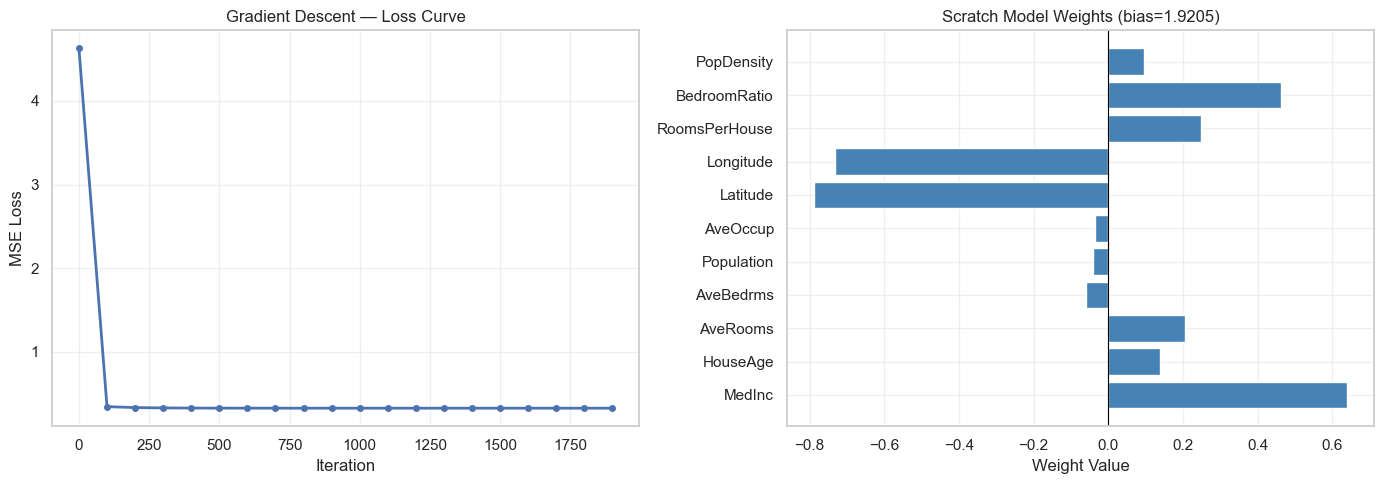

In [69]:
# Loss curve — watch gradient descent converge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(0, 2000, 100), scratch_model.losses, 'b-o', lw=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Gradient Descent — Loss Curve')
axes[0].grid(True, alpha=0.3)

# Learned weights
coef_names = list(X.columns)
axes[1].barh(coef_names, scratch_model.w, color='steelblue')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Weight Value')
axes[1].set_title(f'Scratch Model Weights (bias={scratch_model.b:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Linear Regression with Sklearn

Same result — but in 3 lines, using the Normal Equation under the hood:  
$$\mathbf{w} = (X^T X)^{-1} X^T y$$

In [70]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: {model.intercept_:.4f}\n")
print("Coefficients (by importance):")
for _, row in coef_df.iterrows():
    direction = "+" if row['Coefficient'] > 0 else "-"
    bar = "█" * int(abs(row['Coefficient']) * 5)
    print(f"  {direction} {row['Feature']:<16} {row['Coefficient']:>8.4f}  {bar}")

Intercept: 1.9205

Coefficients (by importance):
  - Latitude          -0.7890  ███
  - Longitude         -0.7332  ███
  + MedInc             0.6393  ███
  + BedroomRatio       0.4653  ██
  + RoomsPerHouse      0.2462  █
  + AveRooms           0.2116  █
  + HouseAge           0.1387  
  + PopDensity         0.0977  
  - AveBedrms         -0.0602  
  - Population        -0.0424  
  - AveOccup          -0.0372  


---
## 9. Evaluation & Overfitting Diagnostics

### 9a. Scratch vs Sklearn — do they match?

In [71]:
# Compare scratch vs sklearn
print("Scratch vs Sklearn comparison:")
print("-" * 50)
print(f"{'Metric':<12} | {'Scratch':<12} | {'Sklearn':<12}")
print("-" * 50)

for name, metric_fn in [('MAE', mean_absolute_error), ('MSE', mean_squared_error), ('R²', r2_score)]:
    sc = metric_fn(y_test, scratch_test_pred)
    sk = metric_fn(y_test, y_test_pred)
    print(f"{name:<12} | {sc:<12.4f} | {sk:<12.4f}")

# Train vs Test — overfitting check
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

print(f"\n{'='*50}")
print(f"Sklearn Train R²: {train_r2:.4f}")
print(f"Sklearn Test  R²: {test_r2:.4f}")
print(f"Gap:              {train_r2 - test_r2:.4f}")

gap = train_r2 - test_r2
if gap > 0.1:
    print("→ OVERFITTING: large train-test gap")
elif test_r2 < 0.5:
    print("→ UNDERFITTING: model too simple")
else:
    print("→ Good generalization")

Scratch vs Sklearn comparison:
--------------------------------------------------
Metric       | Scratch      | Sklearn     
--------------------------------------------------
MAE          | 0.4387       | 0.4387      
MSE          | 0.3474       | 0.3474      
R²           | 0.6376       | 0.6376      

Sklearn Train R²: 0.6510
Sklearn Test  R²: 0.6376
Gap:              0.0134
→ Good generalization


### 9b. Cross-Validation + Learning Curves

5-Fold CV R² Scores:
  Fold 1: 0.6444
  Fold 2: 0.6418
  Fold 3: 0.6442
  Fold 4: 0.6599
  Fold 5: 0.6609

Mean: 0.6502 ± 0.0083


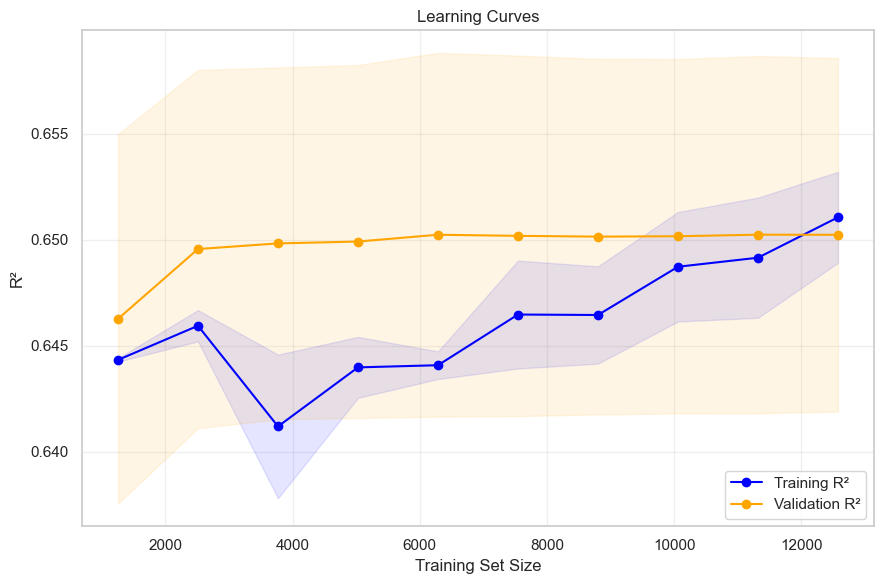

Gap=0.0008 → Good convergence


In [72]:
# 5-fold Cross-Validation
cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')

print("5-Fold CV R² Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2', n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.1, color='orange')
plt.plot(train_sizes, tr_mean, 'o-', color='blue', label='Training R²')
plt.plot(train_sizes, va_mean, 'o-', color='orange', label='Validation R²')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lc_gap = tr_mean[-1] - va_mean[-1]
if lc_gap > 0.1:
    print(f"Gap={lc_gap:.4f} → Overfitting")
elif va_mean[-1] < 0.5:
    print(f"Val R²={va_mean[-1]:.4f} → Underfitting")
else:
    print(f"Gap={lc_gap:.4f} → Good convergence")

---
## 10. Regularization — Ridge & Lasso Comparison

Even if overfitting isn't severe, regularization is a best practice.

| Model | Penalty | Effect |
|-------|---------|--------|
| Ridge (L2) | $\alpha \sum w_j^2$ | Shrinks all weights evenly |
| Lasso (L1) | $\alpha \sum \|w_j\|$ | Zeros out weak features |

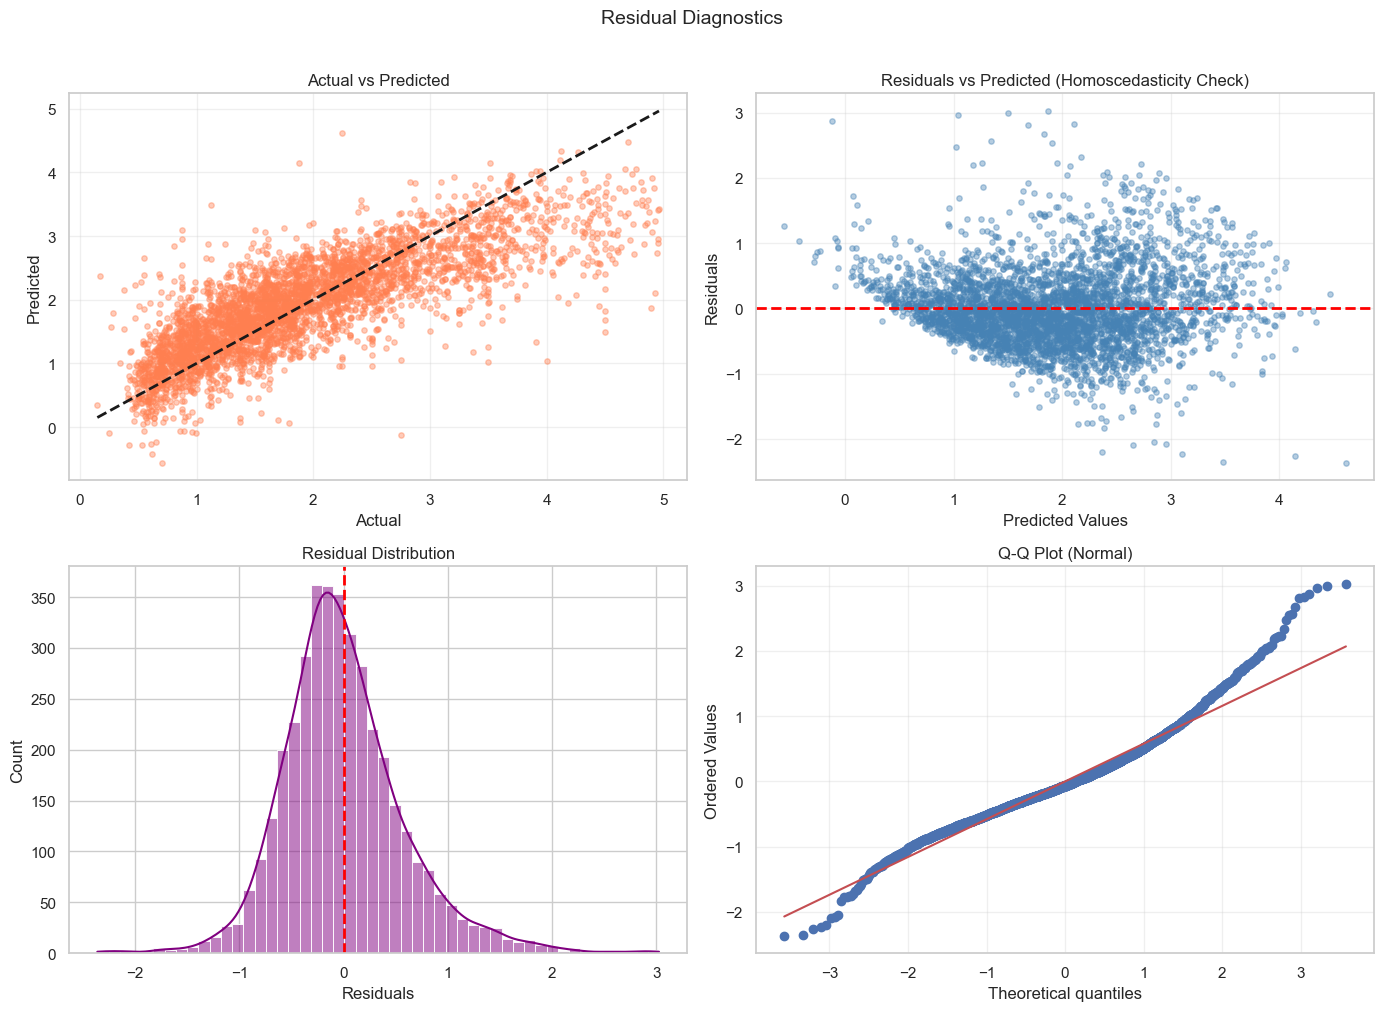

Shapiro-Wilk Test: statistic=0.9585, p-value=0.000000
Residuals are NOT normally distributed (p < 0.05). This is common with real datasets.


In [ ]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []

# Plain LR baseline
results.append({'Model': 'LinearReg', 'Alpha': '-',
                'Train R²': train_r2, 'Test R²': test_r2})

for a in alphas:
    for name, cls in [('Ridge', Ridge(alpha=a)), ('Lasso', Lasso(alpha=a, max_iter=10000))]:
        cls.fit(X_train_scaled, y_train)
        results.append({
            'Model': name, 'Alpha': a,
            'Train R²': r2_score(y_train, cls.predict(X_train_scaled)),
            'Test R²': r2_score(y_test, cls.predict(X_test_scaled)),
        })

results_df = pd.DataFrame(results)
results_df['Gap'] = results_df['Train R²'] - results_df['Test R²']
results_df

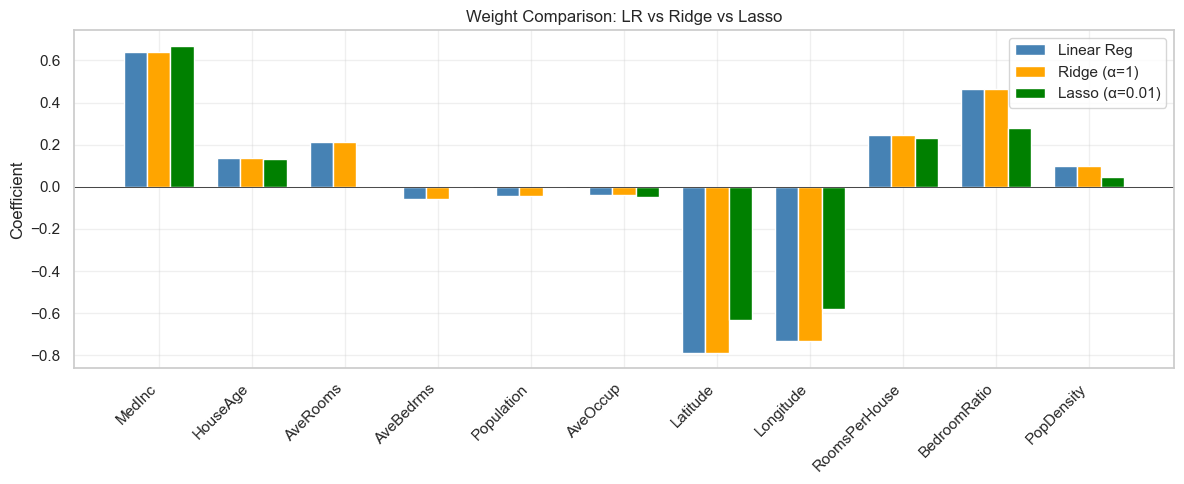

Lasso zeroed out 3/11 features


In [73]:
# Coefficient comparison — LR vs Ridge vs Lasso
ridge_best = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
lasso_best = Lasso(alpha=0.01, max_iter=10000).fit(X_train_scaled, y_train)

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(X.columns))
w = 0.25
ax.bar(x_pos - w, model.coef_, w, label='Linear Reg', color='steelblue')
ax.bar(x_pos,     ridge_best.coef_, w, label='Ridge (α=1)', color='orange')
ax.bar(x_pos + w, lasso_best.coef_, w, label='Lasso (α=0.01)', color='green')
ax.set_xticks(x_pos)
ax.set_xticklabels(X.columns, rotation=45, ha='right')
ax.set_ylabel('Coefficient')
ax.set_title('Weight Comparison: LR vs Ridge vs Lasso')
ax.legend()
ax.axhline(0, color='black', lw=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_zero = (lasso_best.coef_ == 0).sum()
print(f"Lasso zeroed out {n_zero}/{len(X.columns)} features")

---
## 11. Residual Diagnostics

Validate the core assumptions of Linear Regression:
1. **Linearity** — residuals show no curved pattern
2. **Homoscedasticity** — residuals have constant variance across predictions
3. **Normality** — residuals are approximately normal

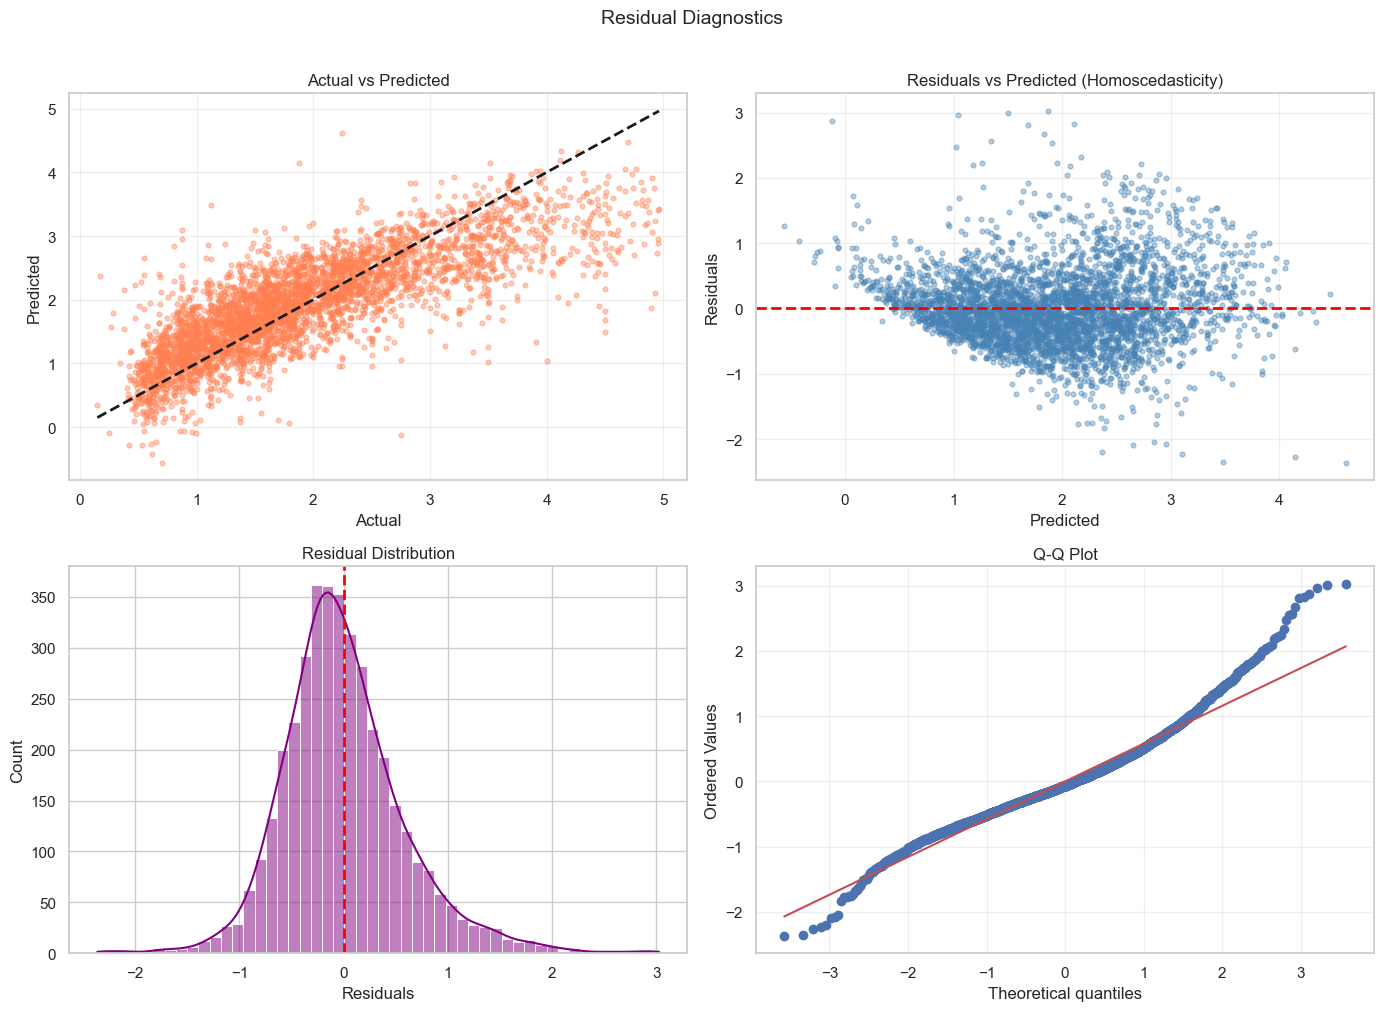

Shapiro-Wilk: stat=0.9585, p=0.000000
Residuals NOT normally distributed (common with real data).


In [74]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.4, color='coral', s=12)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.4, color='steelblue', s=12)
axes[0, 1].axhline(0, color='red', ls='--', lw=2)
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predicted (Homoscedasticity)')
axes[0, 1].grid(True, alpha=0.3)

# Residual histogram
sns.histplot(residuals, bins=50, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', ls='--', lw=2)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_title('Residual Distribution')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Shapiro-Wilk
sample = residuals.sample(min(500, len(residuals)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.6f}")
if p < 0.05:
    print("Residuals NOT normally distributed (common with real data).")
else:
    print("Residuals appear normally distributed.")

---
## 12. Summary

| # | Step | What We Did | Why |
|---|------|------------|-----|
| 1 | **Data Loading** | Load California Housing, inspect shape/types | Understand the raw data |
| 2 | **EDA** | Distributions, correlation heatmap, pairplots, capped-value removal | Find patterns, remove censored rows |
| 3 | **Outlier Treatment** | IQR capping on all numeric features | Prevent extreme points from distorting OLS |
| 4 | **Feature Engineering** | `RoomsPerHouse`, `BedroomRatio`, `PopDensity` + skewness log transform | Create meaningful signals + fix distribution |
| 5 | **Feature Selection** | Correlation filter + VIF analysis | Drop weak features + detect multicollinearity |
| 6 | **Preprocessing** | StandardScaler + 80/20 train/test split | Fair coefficient comparison + prevent leakage |
| 7 | **LR from Scratch** | Gradient descent with NumPy | Understand the math behind LR |
| 8 | **LR with Sklearn** | Normal equation (closed-form) | Production-ready model |
| 9 | **Evaluation** | Train/Test R², 5-fold CV, learning curves | Diagnose bias-variance trade-off |
| 10 | **Regularization** | Ridge (L2) & Lasso (L1) across alphas | Control overfitting + automatic feature selection |
| 11 | **Residual Diagnostics** | Residual plots, Q-Q plot, Shapiro-Wilk test | Validate LR assumptions |

### Key Takeaways
- Remove censored/capped target values before training
- Outlier treatment and skewness correction improve robustness
- Feature engineering + selection boosts signal-to-noise ratio
- Scratch implementation matches sklearn — gradient descent works
- Cross-validation and learning curves are more reliable than a single split
- Regularization is always worth trying — Lasso doubles as feature selection
- Residual diagnostics reveal if the model's assumptions hold